In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from scipy.stats import norm
from scipy.optimize import minimize
import os

/Users/stephensefa/anaconda3/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:430: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


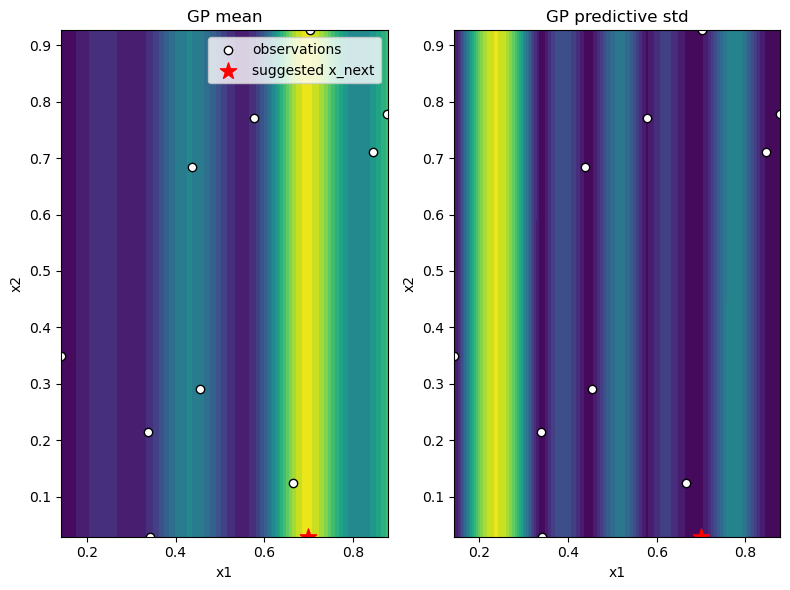

Suggested next evaluation point saved to: suggested_next_point.npy
Suggested x_next: [0.69872802 0.02869672]
Current best y (min): 0.6112052157614438


In [3]:
# ---- User config ----
INPUT_PATH = "initial_inputs.npy"      # path to X .npy
OUTPUT_PATH = "initial_outputs.npy"    # path to y .npy
SAVE_SUGGEST = "suggested_next_point.npy"
MINIMISE = False         # set False if you are maximising
GRID_CANDIDATES = 8000
N_RESTARTS = 12

# ---- Load data ----
if not (os.path.exists(INPUT_PATH) and os.path.exists(OUTPUT_PATH)):
    raise FileNotFoundError("Put initial_inputs.npy and initial_outputs.npy in the working directory")

X = np.load(INPUT_PATH)
y = np.load(OUTPUT_PATH)

# ensure shapes
X = X.reshape(-1, X.shape[-1]) if X.ndim > 1 else X.reshape(-1,1)
y = y.reshape(-1)

n_samples, d = X.shape

# ---- Fit GP ----
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=np.ones(d), length_scale_bounds=(1e-2,1e2)) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-8,1e1))
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=5)
gp.fit(X, y)

# ---- Bounds (inferred from data) ----
mins = X.min(axis=0)
maxs = X.max(axis=0)
margin = 1e-6
bounds = [(float(mins[i]-margin), float(maxs[i]+margin)) for i in range(d)]

# ---- Expected Improvement (minimisation) ----
def expected_improvement(x, gp, y_best, xi=1e-3):
    x = np.asarray(x).reshape(1, -1)
    mu, sigma = gp.predict(x, return_std=True)
    mu = mu.ravel()[0]
    sigma = sigma.ravel()[0]
    if sigma <= 0:
        return 0.0
    imp = (y_best - mu - xi) if MINIMISE else (mu - y_best - xi)
    Z = imp / sigma
    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    return float(ei)

# ---- Propose next point by maximizing EI ----
def propose_next_point(gp, bounds, y_best, n_grid=GRID_CANDIDATES, n_restarts=N_RESTARTS):
    d = len(bounds)
    lb = np.array([b[0] for b in bounds])
    ub = np.array([b[1] for b in bounds])
    candidates = np.random.uniform(lb, ub, size=(n_grid, d))
    eis = np.array([expected_improvement(c, gp, y_best) for c in candidates])
    best_idx = int(np.nanargmax(eis))
    x0 = candidates[best_idx]

    def neg_ei(x):
        return -expected_improvement(x, gp, y_best)

    best = x0.copy()
    best_val = -neg_ei(x0)
    for i in range(n_restarts):
        x_init = np.random.uniform(lb, ub)
        res = minimize(neg_ei, x_init, bounds=bounds, method='L-BFGS-B')
        if res.success and -res.fun > best_val:
            best_val = -res.fun
            best = res.x.copy()

    # fallback to max variance if EI is numerically zero everywhere
    if best_val <= 1e-12:
        _, stds = gp.predict(candidates, return_std=True)
        best = candidates[np.argmax(stds)]
    return best

y_best = np.min(y) if MINIMISE else np.max(y)
x_next = propose_next_point(gp, bounds, y_best)

# save
np.save(SAVE_SUGGEST, x_next)

# ---- Plot results ----
plt.figure(figsize=(8,6))
if d == 1:
    xx = np.linspace(bounds[0][0], bounds[0][1], 400).reshape(-1,1)
    mu, std = gp.predict(xx, return_std=True)
    plt.plot(X.ravel(), y, 'ko', label='observations')
    plt.plot(xx.ravel(), mu, label='GP mean')
    plt.fill_between(xx.ravel(), mu-std, mu+std, alpha=0.3, label='GP ±1σ')
    plt.axvline(x_next.ravel()[0], color='red', linestyle='--', label='suggested x_next')
    plt.title('GP fit and suggested next point')
    plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.tight_layout(); plt.show()

elif d == 2:
    n = 120
    x1 = np.linspace(bounds[0][0], bounds[0][1], n)
    x2 = np.linspace(bounds[1][0], bounds[1][1], n)
    X1g, X2g = np.meshgrid(x1, x2)
    grid = np.column_stack([X1g.ravel(), X2g.ravel()])
    mu, std = gp.predict(grid, return_std=True)
    MU = mu.reshape(n, n)
    STD = std.reshape(n, n)

    plt.subplot(1,2,1)
    plt.contourf(X1g, X2g, MU, levels=20)
    plt.scatter(X[:,0], X[:,1], c='white', edgecolors='k', label='observations')
    plt.scatter([x_next[0]], [x_next[1]], c='red', marker='*', s=150, label='suggested x_next')
    plt.title('GP mean'); plt.xlabel('x1'); plt.ylabel('x2'); plt.legend()

    plt.subplot(1,2,2)
    plt.contourf(X1g, X2g, STD, levels=20)
    plt.scatter(X[:,0], X[:,1], c='white', edgecolors='k')
    plt.scatter([x_next[0]], [x_next[1]], c='red', marker='*', s=150)
    plt.title('GP predictive std'); plt.xlabel('x1'); plt.ylabel('x2')

    plt.tight_layout(); plt.show()

else:
    # d > 2: plot 2D projection of first two dims and mark suggestion
    plt.scatter(X[:,0], X[:,1], c='k', label='observations')
    plt.scatter([x_next[0]], [x_next[1]], c='red', marker='*', s=150, label='suggested x_next (proj)')
    plt.title('Projection of observations (first two dims)'); plt.xlabel('x1'); plt.ylabel('x2'); plt.legend(); plt.tight_layout(); plt.show()

# ---- Final printout ----
print("Suggested next evaluation point saved to:", SAVE_SUGGEST)
print("Suggested x_next:", x_next)
print("Current best y (min):", float(y_best))
